# Reproducing the supporting Python workflow

The main research material is [Ibrahim’s combined study](medulloblastoma_study.ipynb) and [report](../REPORT.md). This separate notebook demonstrates the Python package added during consolidation. It uses **synthetic data by default** so it runs without downloading the original research inputs. Its scores are software checks, not the original assessment results.

The recorded full packaged run is examined at the end. See [data requirements](../docs/DATA.md) and [method notes](../docs/METHODOLOGY.md) for how this later workflow differs from the original study.

## 1. Choose the input boundary

Install the package with `python -m pip install -e '.[dev]'`. Keep labels and sample identifiers separate from CpG measurements. To inspect local cohort data, set `USE_PREPARED_COHORT = True` and supply the four documented files. Raw IDAT normalization is outside the reproduced scope.

In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

from mb_classifier.data import load_prepared_data, make_demo_data
from mb_classifier.modeling import fit_benchmark
from mb_classifier.reporting import render_report

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
USE_PREPARED_COHORT = False
DATA_DIR = ROOT / "data" / "raw"
dataset = load_prepared_data(DATA_DIR) if USE_PREPARED_COHORT else make_demo_data(seed=42)
print("Input mode:", dataset.mode)
print("CpG input features:", dataset.summary["n_features"])

Input mode: demo
CpG input features: 96


## 2. Audit sample identity and class balance

Training and held-out IDs must be disjoint. The two validation representations share specimen IDs, and their counts must not be added as independent patients. Subtype labels are categories, rather than ordered integers.

,train,test,hm450_validation,epic_validation
subtype,,,,
1,12,4,3,3
2,12,4,3,3
3,12,4,3,3
4,12,4,3,3
5,12,4,3,3
6,12,4,3,3
7,12,4,3,3
8,12,4,3,3


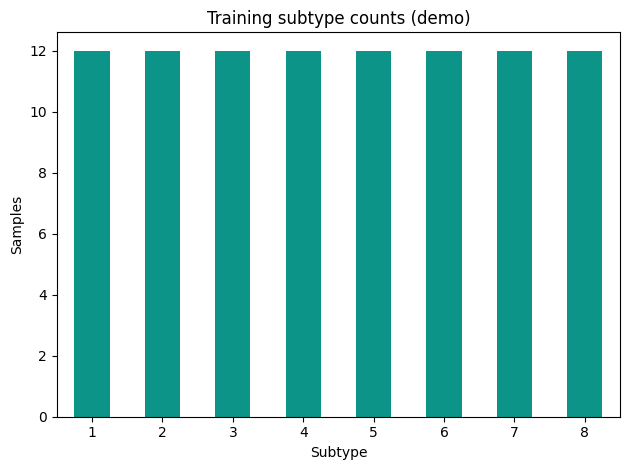

In [2]:
cohorts = dataset.cohorts
counts = (
    pd.DataFrame({name: cohort.y.value_counts().sort_index() for name, cohort in cohorts.items()})
    .fillna(0)
    .astype(int)
)
display(counts)
assert set(cohorts["train"].X.index).isdisjoint(cohorts["test"].X.index)
assert "subtype" not in cohorts["train"].X.columns
assert cohorts["epic_validation"].X.index.isin(cohorts["hm450_validation"].X.index).all()
counts["train"].plot.bar(color="#0d9488", title=f"Training subtype counts ({dataset.mode})", rot=0)
plt.xlabel("Subtype")
plt.ylabel("Samples")
plt.tight_layout()
plt.show()

## 3. Inspect beta-value quality

Beta values should be finite and fall in [0,1]. A histogram is descriptive quality control: it does not prove correct normalization or remove batch effects. The prepared-cohort loader checks these contracts before fitting.

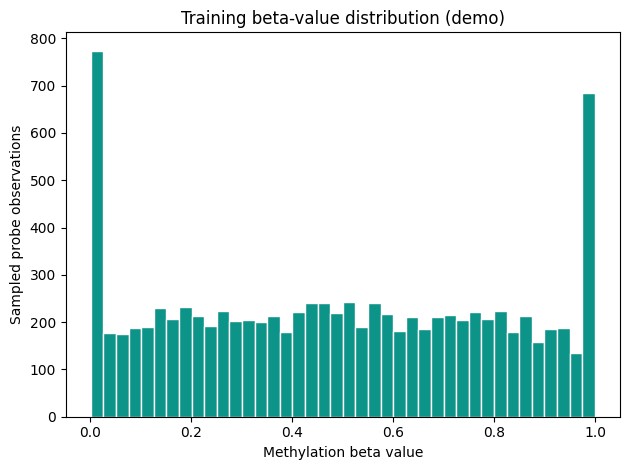

In [3]:
train = cohorts["train"]
values = train.X.to_numpy()
assert np.isfinite(values).all() and ((values >= 0) & (values <= 1)).all()
plt.hist(
    values.ravel()[:: max(1, values.size // 100000)], bins=40, color="#0d9488", edgecolor="white"
)
plt.title(f"Training beta-value distribution ({dataset.mode})")
plt.xlabel("Methylation beta value")
plt.ylabel("Sampled probe observations")
plt.tight_layout()
plt.show()

## 4. Train without leaking fold information

The NMF candidate fits variance selection, factorization, scaling and class-weighted SVC inside each cross-validation fold. It is compared with a direct linear SVM and a majority-class dummy. Training macro F1 selects the winner; the hold-outs are evaluated afterwards. The synthetic demo uses fewer probes and ranks than the real-cohort profile.

In [4]:
RUN_DIR = ROOT / "reports" / ("notebook_cohort" if USE_PREPARED_COHORT else "notebook_demo")
summary = fit_benchmark(dataset, RUN_DIR, profile="quick", seed=42)
render_report(RUN_DIR)
display(pd.DataFrame(summary["selection"]["candidates"]).T)
print("Selected model:", summary["selection"]["winner"])
print("Convergence warnings:", summary["convergence_warnings"])

Fitting nmf_svm: 2 training folds, 96 selected probes


Fitting linear_svm: 2 training folds, 96 selected probes


Fitting dummy: 2 training folds, 96 selected probes


Selected nmf_svm by training CV macro F1: 1.0000


,cv_macro_f1,best_params
nmf_svm,1.0,"{'classifier__C': 0.1, 'classifier__kernel': '..."
linear_svm,1.0,{'classifier__C': 0.1}
dummy,0.027778,{}


Selected model: nmf_svm
Convergence warnings: []


## 5. Evaluate every class and representation

Macro F1 and balanced accuracy complement overall accuracy. Micro F1 equals accuracy for this single-label multiclass task. Wilson intervals quantify sampling uncertainty for accuracy only; they do not account for upstream data preparation or retrospective model development.

,model,split,n_samples,accuracy,balanced_accuracy,macro_f1
0,nmf_svm,test,32,1.000,1.000,1.0000
1,nmf_svm,hm450_validation,24,1.000,1.000,1.0000
2,nmf_svm,epic_validation,24,1.000,1.000,1.0000
3,linear_svm,test,32,1.000,1.000,1.0000
4,linear_svm,hm450_validation,24,1.000,1.000,1.0000
5,linear_svm,epic_validation,24,1.000,1.000,1.0000
6,dummy,test,32,0.125,0.125,0.0278
7,dummy,hm450_validation,24,0.125,0.125,0.0278
8,dummy,epic_validation,24,0.125,0.125,0.0278


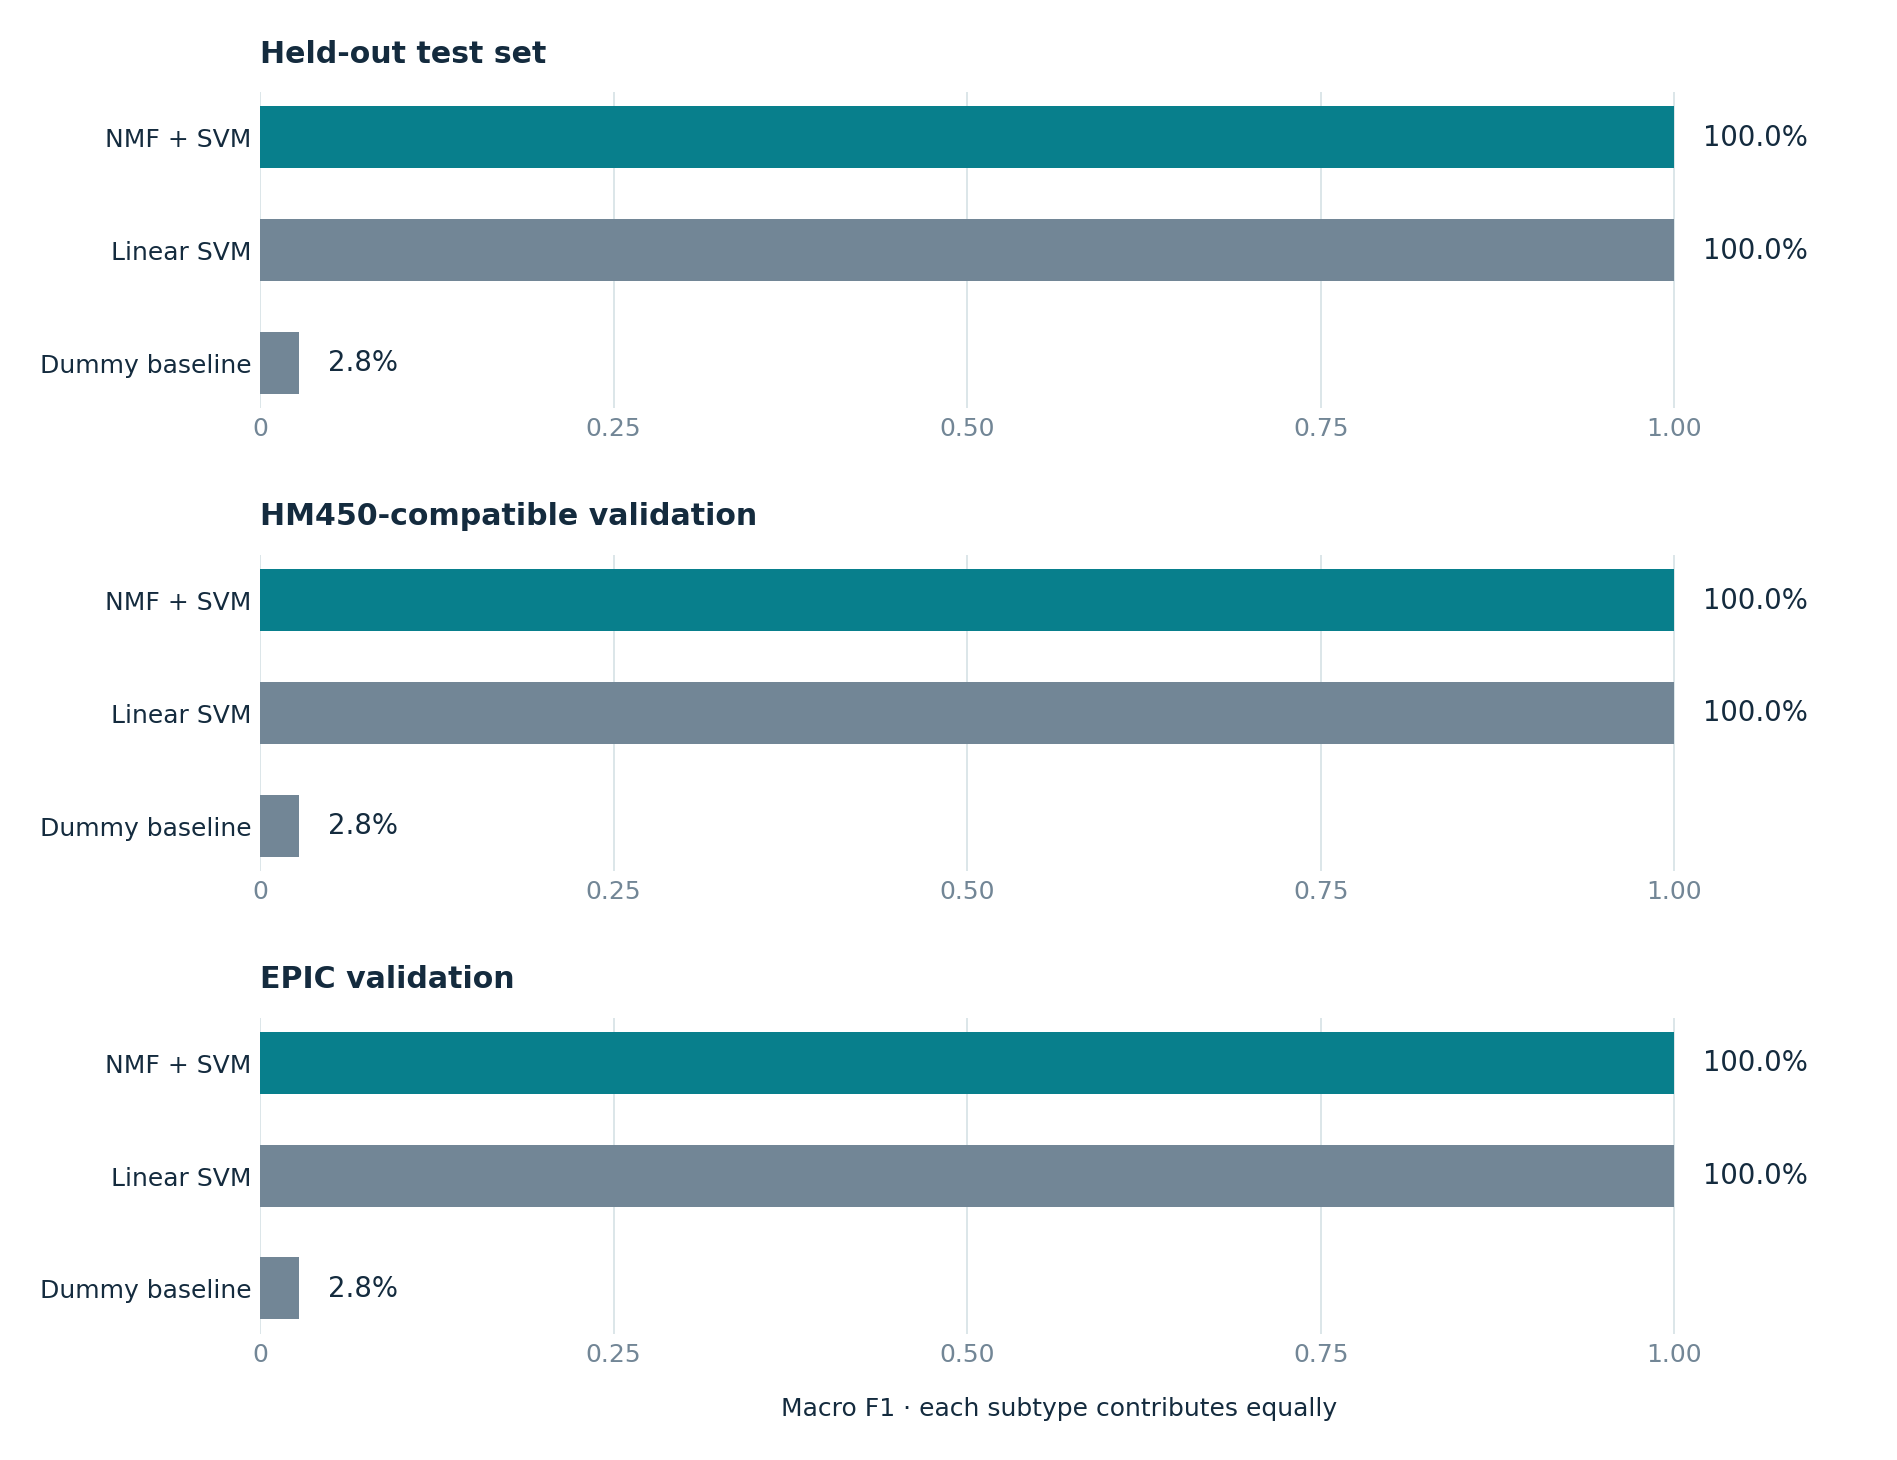

Paired validation: {'n_pairs': 24, 'prediction_agreement': 1.0}


In [5]:
results = pd.DataFrame(summary["evaluations"])
display(
    results[["model", "split", "n_samples", "accuracy", "balanced_accuracy", "macro_f1"]].round(4)
)
display(Image(filename=str(RUN_DIR / "figures" / "model-comparison.png")))
print("Paired validation:", summary["paired_validation"])

## 6. Reuse the fitted model

The saved model contains its complete training schema and fitted preprocessing. New columns are restored to training order before prediction. Missing probes cause an explicit error. The command-line equivalent is documented in the [data guide](../docs/DATA.md). Load joblib artifacts only from trusted runs.

In [6]:
bundle = joblib.load(RUN_DIR / "model.joblib")
held_out = cohorts["test"]
prediction = bundle["pipeline"].predict(held_out.X[bundle["feature_names"]].to_numpy())
display(pd.DataFrame({"reference": held_out.y, "predicted": prediction}).head(8))

,reference,predicted
synthetic-test-000,1,1
synthetic-test-001,1,1
synthetic-test-002,1,1
synthetic-test-003,1,1
synthetic-test-004,2,2
synthetic-test-005,2,2
synthetic-test-006,2,2
synthetic-test-007,2,2


## 7. Read the recorded prepared-cohort evidence

These aggregate files were produced using the supplied methylation matrices, rather than the synthetic example above. The test cohort is retrospective. The 99 processed and 97 EPIC validation rows are paired representations of overlapping sample records. Upstream curation of the 22,892-probe universe is inherited and cannot be fully audited from the source bundle.

In [7]:
for profile, folder in [("full", "benchmark_full")]:
    path = ROOT / "reports" / folder / "metrics.json"
    if path.exists():
        recorded = json.loads(path.read_text())
        print(profile, "prepared cohort; selected:", recorded["selection"]["winner"])
        table = pd.DataFrame(recorded["evaluations"])
        display(
            table[table.model == recorded["selection"]["winner"]][
                ["split", "n_samples", "accuracy", "macro_f1", "balanced_accuracy"]
            ].round(4)
        )
        print("Paired prediction agreement:", recorded["paired_validation"])

full prepared cohort; selected: nmf_svm


,split,n_samples,accuracy,macro_f1,balanced_accuracy
0,test,255,0.9804,0.9722,0.9704
1,hm450_validation,99,0.9394,0.9217,0.9541
2,epic_validation,97,0.9381,0.9190,0.9519


Paired prediction agreement: {'n_pairs': 97, 'prediction_agreement': 1.0}


## Interpretation and next steps

The combined project demonstrates auditable sample handling, fold-specific transformations, reproducible model selection and explicit evaluation. It does not demonstrate a diagnostic device or independent external clinical validation. A future study would specify raw processing completely and evaluate a frozen pipeline on a new cohort.

Sources: [Sharma et al., 2019](https://doi.org/10.1007/s00401-019-02020-0), [Abid and Rafiee, 2025](https://arxiv.org/abs/2510.02416), [GEO GSE130051](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE130051).